In [1]:
import tensorflow as tf 

gpus = tf.config.list_physical_devices("GPU")

print(gpus)

2025-02-19 15:56:38.936652: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-19 15:56:38.962696: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-19 15:56:38.962712: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-19 15:56:38.963443: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-19 15:56:38.968904: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import sys
sys.path.append('/home/alumnos/mburgosc/tfg/egm_reconstruction/Code/tools_')
import tools

In [3]:
from tools import *

In [4]:
import sys, os


from scipy.io import loadmat
import numpy as np
from random import randint
import matplotlib.pyplot as plt
from itertools import product
from numpy.random import default_rng
import scipy.io
import h5py
from scipy import signal as sigproc
from scipy.interpolate import interp1d
from math import floor
from scipy import signal
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import tensorflow as tf
import random
import math
from sklearn.metrics import mean_squared_error
from fastdtw import fastdtw
import time
import keras
from keras import models, layers
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from tensorflow.keras import datasets, layers, models, losses, Model
from generators import *
from numpy import reshape
import matplotlib.image
from scipy.io import savemat
#from plots import *
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from datetime import time


In [5]:
data_short_dir = "/home/alumnos/mburgosc/tfg/egm_reconstruction/Data_short"
egms_all_models = load_egms_df(data_short_dir)

data ['Simulation_01_210209_001_002', 'LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_201223_001_002', 'Simulation_01_190619_001_004', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'RA_RAA_141230', 'Simulation_01_200316_001_  1', 'TwoRotors_181219', 'RA_RAFW_SAF_140730', 'Simulation_01_200212_001_  4']


In [6]:
print(egms_all_models)

                              id  \
0   Simulation_01_210209_001_002   
1             LA_RSPV_CAF_150115   
2   Simulation_01_200428_001_001   
3   Simulation_01_201223_001_002   
4   Simulation_01_190619_001_004   
5   Simulation_01_190502_001_004   
6                 RA_RAFW_140807   
7                  RA_RAA_141230   
8   Simulation_01_200316_001_  1   
9               TwoRotors_181219   
10            RA_RAFW_SAF_140730   
11  Simulation_01_200212_001_  4   

                                            AF_signal  
0   [[9.479828179102282e-14, 0.04080228461795585, ...  
1   [[7.387776530722087, 9.094867906767199, 10.800...  
2   [[0.8807414426522221, 1.015404814148348, 0.963...  
3   [[4.24492593645743, 4.6424979299912765, 5.0315...  
4   [[-50.648764509652416, -48.25332554580271, -44...  
5   [[-61.093924858397685, -56.059614688222744, -5...  
6   [[-15.990956008585043, -14.190372868776846, -1...  
7   [[-1.5399639907851848, -1.421404688195314, -1....  
8   [[2.593443248791235, 2.

In [7]:
egms_values = egms_all_models["AF_signal"].tolist()
print(egms_values[0].shape)
print(len(egms_values))


(2048, 1500)
12


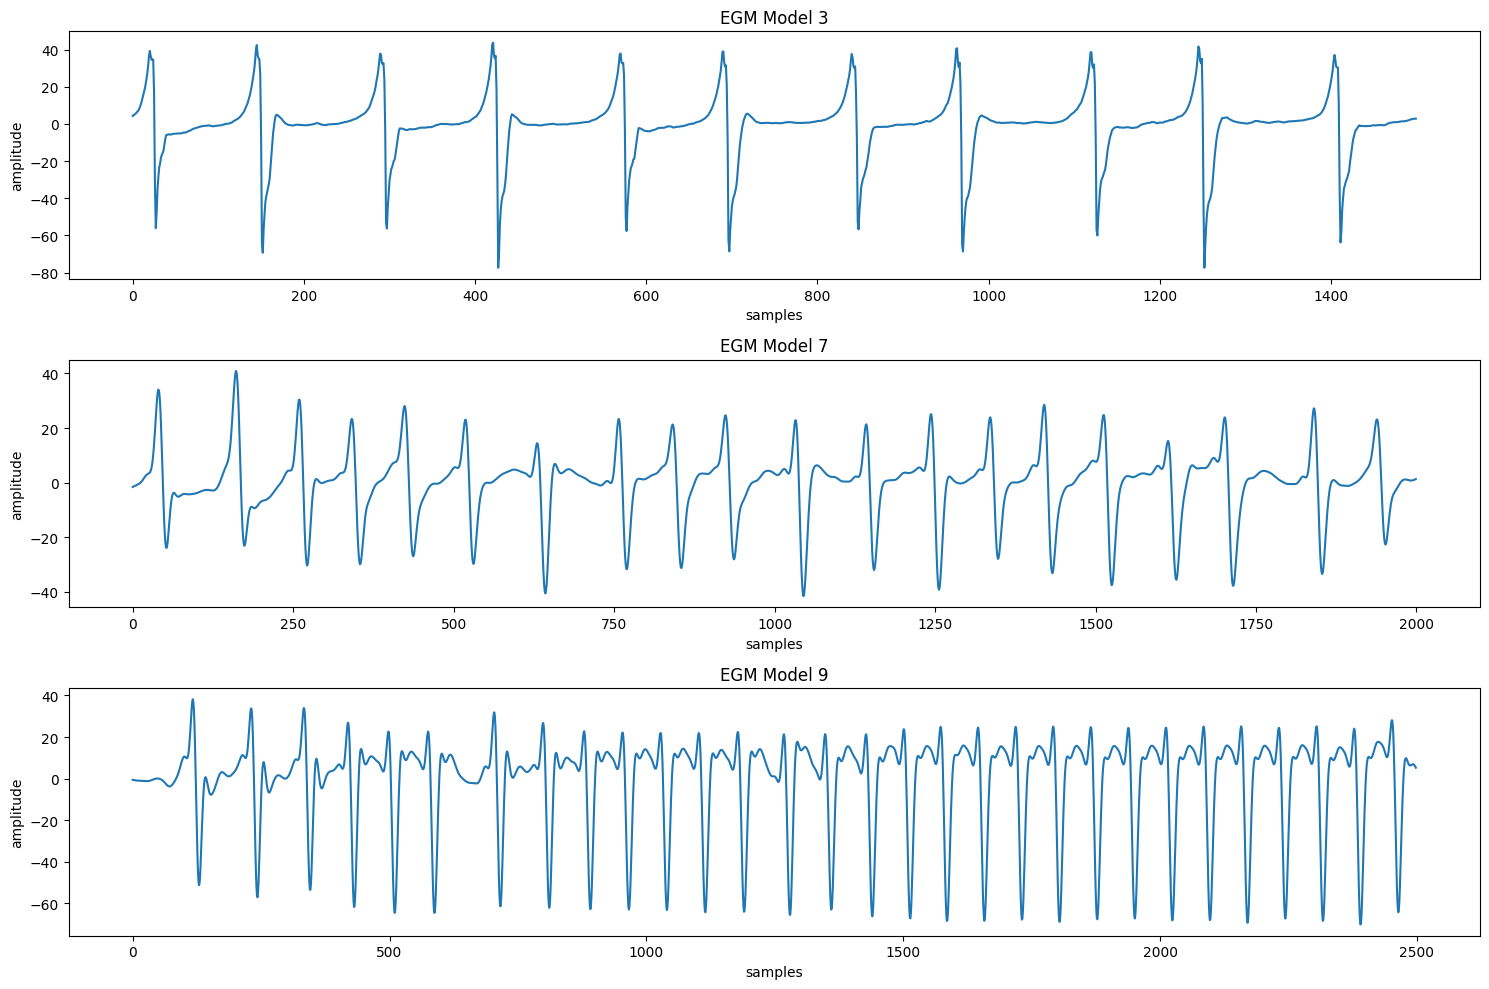

In [8]:
#plotting egms

import random

random_indices = random.sample(range(len(egms_values)), 3)
fig, axs = plt.subplots(3, 1, figsize=(15, 10))

for i, idx in enumerate(random_indices):
    axs[i].plot(egms_values[idx][0, :]) 
    axs[i].set_title(f'EGM Model {idx}')  
    axs[i].set_xlabel('samples')
    axs[i].set_ylabel('amplitude')

plt.tight_layout()
plt.show()


In [9]:

from tools import ECG_filtering  #NO ESTA ENCONTRANDO LA FUNCIÓN ASIQUE LA PEGO A MANO

def ECG_filtering(signal, fs, order = 2, f_low=3, f_high=60):
    """
    Frequency filtering of ECG-EGM.
    SR model: low-pass filtering, 4th-order Butterworth filter.
    FA models: bandpass filtering, 4th-order Butterworth filter.

    Parameters:
        signal (array): signal to process
        fs (int): sampling rate
        f_low (int-float): low cut-off frecuency (default=3Hz)
        f_high (int-float): high cut-off frecuency (default=30Hz)
        model (string): FA model to assess (default: SR)
    Returns:
        proc_ECG_EGM (array): filtered ECG-EGM
    """

    # Remove DC component
    sig_temp = remove_mean(signal)
    #sig_temp = signal

    # Bandpass filtering
    b, a = sigproc.butter(
        order, [f_low / round((fs / 2)), f_high / round((fs / 2))], btype="bandpass"
    )

    proc_ECG_EGM = np.zeros(sig_temp.shape)
    if sig_temp.ndim ==3:
        for i in range(sig_temp.shape[1]):  
            for j in range(sig_temp.shape[2]):  
                #for index in range(sig_temp.shape[0]):
                proc_ECG_EGM[:, i, j] = sigproc.filtfilt(b, a, sig_temp[:, i, j])
    else: 
        for index in range(0, sig_temp.shape[0]):
            proc_ECG_EGM[index, :] = sigproc.filtfilt(b, a, sig_temp[index, :])

    return proc_ECG_EGM


egms_filtered_norm = []

for i in range(len(egms_values)):
    
    #ECG FILTERING
    egms = egms_values[i]
    print(egms.shape)
    egms_filt = ECG_filtering(egms.T, 500)
    


    #NORMLIZE EGMS
    high = 1
    low = -1

    mins = np.min(egms_filt, axis=0)
    maxs = np.max(egms_filt, axis=0)
    rng = maxs - mins

    norm_egms = high - (((high - low) * (maxs - egms_filt)) / rng)
    
    norm_egms = norm_egms.T #para que queden otra vez (2048 x samples of time)
    egms_filtered_norm.append(norm_egms)



(2048, 1500)
(2048, 2499)
(2048, 1301)
(2048, 1500)
(2048, 4000)
(2048, 4000)
(2048, 2000)
(2048, 2000)
(2048, 2001)
(2048, 2499)
(2048, 2499)
(2048, 4501)


In [10]:
print(len(egms_filtered_norm))
print(egms_filtered_norm[0].shape)

#PREGUNTAR A OSCAR SI DEBERÍA ACOTAR TODOS A UN TIEMPO, POR EJEMPLO 1000 UNIDADES DE TIEMPO --> si hago esto puedo convertirlos en np arrays


12
(2048, 1500)


In [11]:
print(egms_filtered_norm[0][0, :].shape)

(1500,)


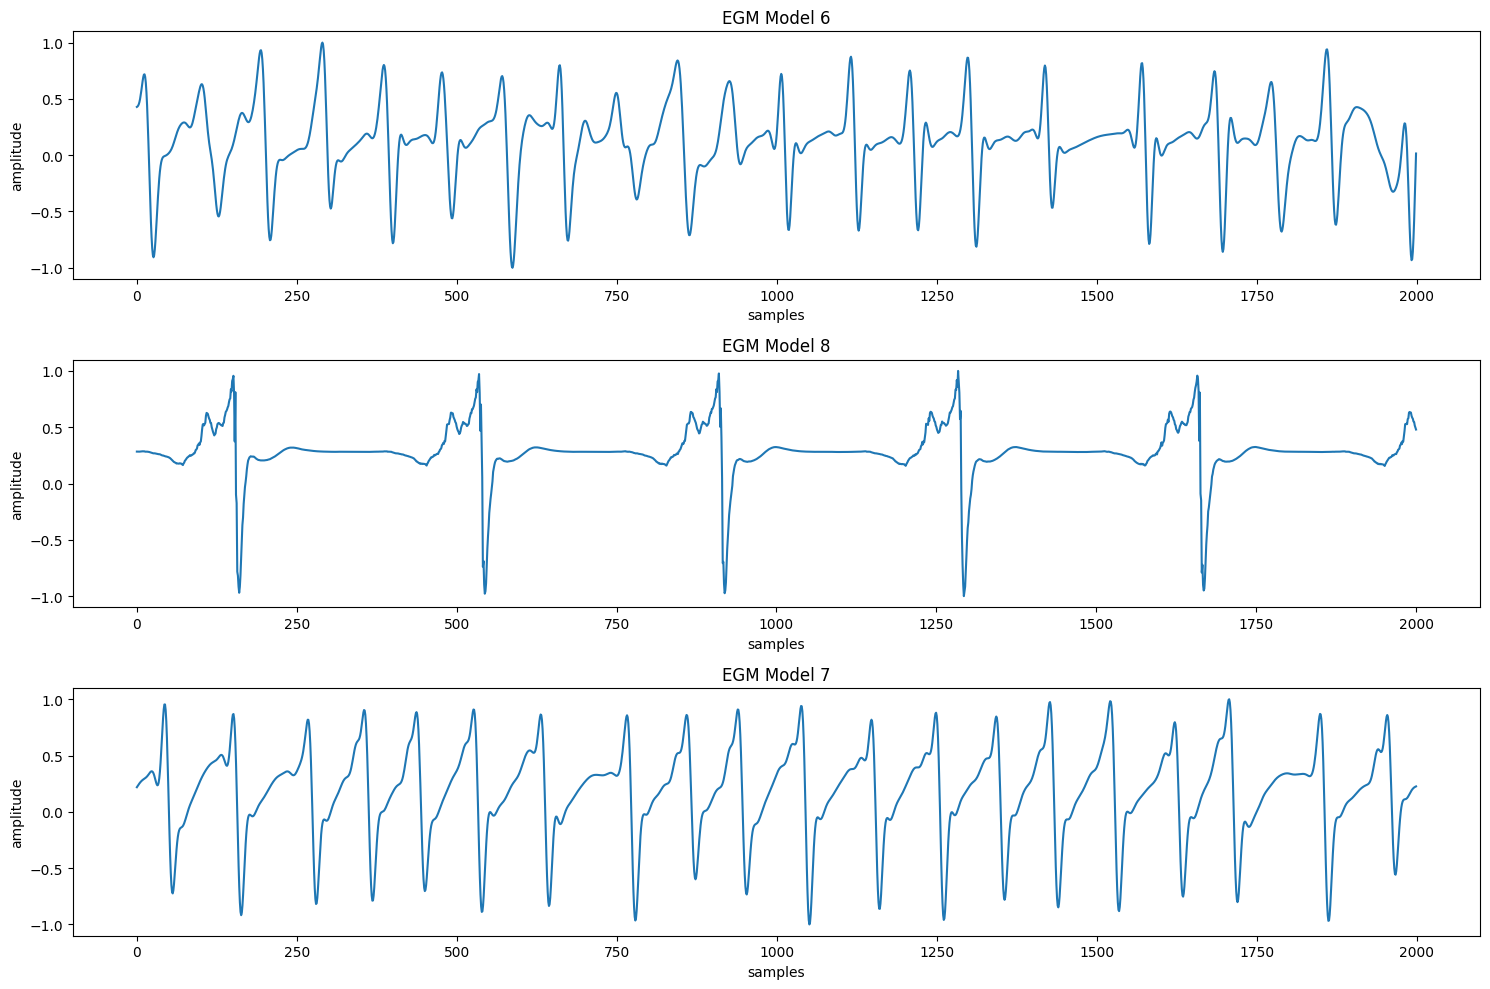

In [12]:
#plotting egms filtered and normalized

random_ind = random.sample(range(len(egms_filtered_norm)), 3)
fig, axs = plt.subplots(3, 1, figsize=(15, 10))

for i, idx in enumerate(random_ind):
    axs[i].plot(egms_filtered_norm[idx][0, :]) 
    axs[i].set_title(f'EGM Model {idx}')  
    axs[i].set_xlabel('samples')
    axs[i].set_ylabel('amplitude')

plt.tight_layout()
plt.show()

In [13]:
transfer_matrices = load_transfer(ten_leads=False, bsps_set=False)

In [14]:

print(transfer_matrices[0][1].shape) #--> 64 electrodes 
print(transfer_matrices[0][0].shape)
print(transfer_matrices[1][0].shape)
print(transfer_matrices[1][1].shape) 

(64, 1)
(3610, 2048)
(3970, 2048)
(64, 1)


In [15]:
#COMPUTING THE FORWARD PROBLEM

# y = A*x --> y: bsps, A: transfer matrix, x: egms
# A =  (3018x2048) --> 3018 nodos en el torso de los 64 electrodos 
#                  --> 2048 electrodos en la auricula 
# x = (2048x1000)  --> 1000 samples of time
# y = (3018x1000)  

A = transfer_matrices[0]

print(A)
print(A[1].shape) #--> matriz de transferencia

bsps_all_models = []
for i in range(len(egms_filtered_norm)):

    y_f = forward_problem(egms_filtered_norm[i], A[0]) # bsps
    bsps_all_models.append(y_f)


(array([[ 7.69965054e-05,  7.34290114e-05,  5.55983500e-05, ...,
        -4.30014225e-04,  3.20904568e-03,  2.03465098e-03],
       [-1.46424028e-04, -1.47995566e-04, -6.64696334e-05, ...,
         6.82507351e-04, -1.64109737e-03, -7.97225589e-04],
       [-1.17874811e-04, -1.11635205e-04, -5.44792074e-05, ...,
        -2.10877594e-04, -1.42770170e-03, -1.17830147e-03],
       ...,
       [-4.31684863e-05, -3.11358531e-05, -1.69536380e-05, ...,
        -1.81270509e-04, -4.25855593e-05, -2.64389011e-04],
       [-9.15845321e-05, -8.35069368e-05, -4.04402041e-05, ...,
        -4.26394139e-04, -9.76937571e-04, -9.75087733e-04],
       [-5.75701441e-05, -4.84485410e-05, -3.20869635e-05, ...,
         2.06745799e-04, -1.04379968e-03, -9.80077168e-04]]), array([[ 552],
       [3422],
       [2994],
       [  46],
       [ 971],
       [2982],
       [ 520],
       [ 522],
       [3502],
       [3188],
       [ 674],
       [ 472],
       [2694],
       [2641],
       [  18],
       [  40],
 

In [16]:
print(bsps_all_models[0].shape)

(3610, 1500)


(2499,)
(2499,)
(2000,)


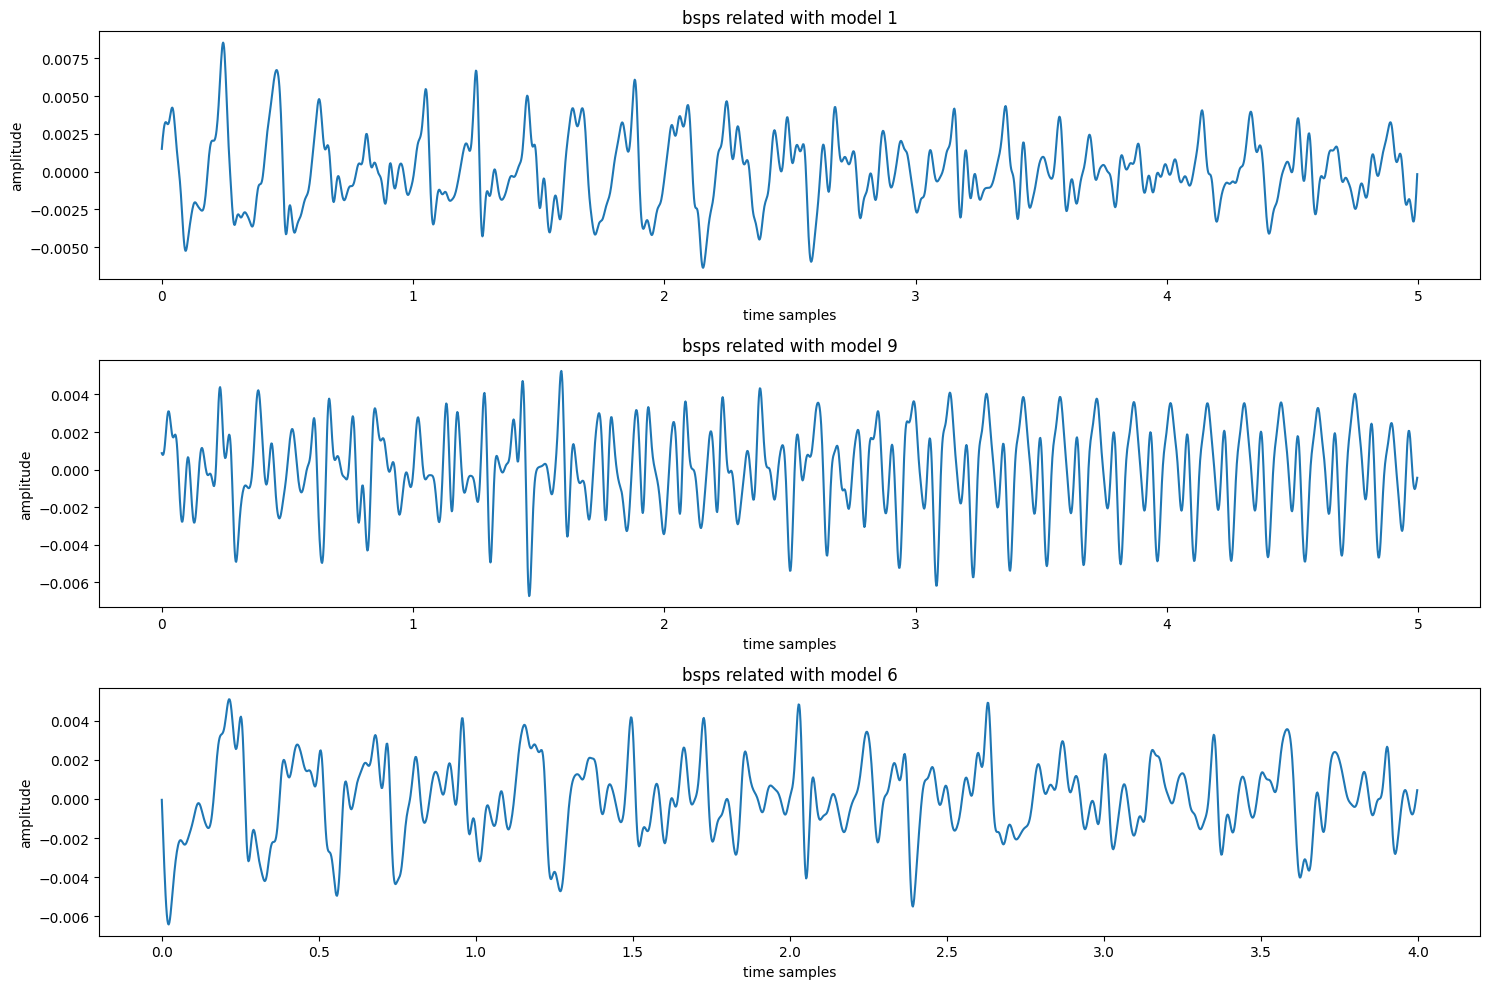

In [17]:
#plotting bsps --> 3 random models 1st node

random_ind = random.sample(range(len(bsps_all_models)), 3)
fig, axs = plt.subplots(3, 1, figsize=(15, 10))

for i, idx in enumerate(random_ind):
    signal = bsps_all_models[idx][0, :] -np.mean(bsps_all_models[idx][0, :])

    t = np.arange(len(signal))/500
    print(t.shape)
    axs[i].plot(t, signal) 
    axs[i].set_title(f'bsps related with model {idx}')  
    axs[i].set_xlabel('time samples')
    axs[i].set_ylabel('amplitude')

plt.tight_layout()
plt.show()

In [18]:
#nos quedamos con 64 nodos para los bsps como chaqueta
bsps_64_all_models = []
for i in range(len(bsps_all_models)):

    bsps_64 = bsps_all_models[i][A[1].ravel(),:]
    print(bsps_64.shape)
    bsps_64_all_models.append(bsps_64)

    
print()
print(bsps_64_all_models[0].shape)
print(bsps_64_all_models[0][0,:].shape)

(64, 1500)
(64, 2499)
(64, 1301)
(64, 1500)
(64, 4000)
(64, 4000)
(64, 2000)
(64, 2000)
(64, 2001)
(64, 2499)
(64, 2499)
(64, 4501)

(64, 1500)
(1500,)


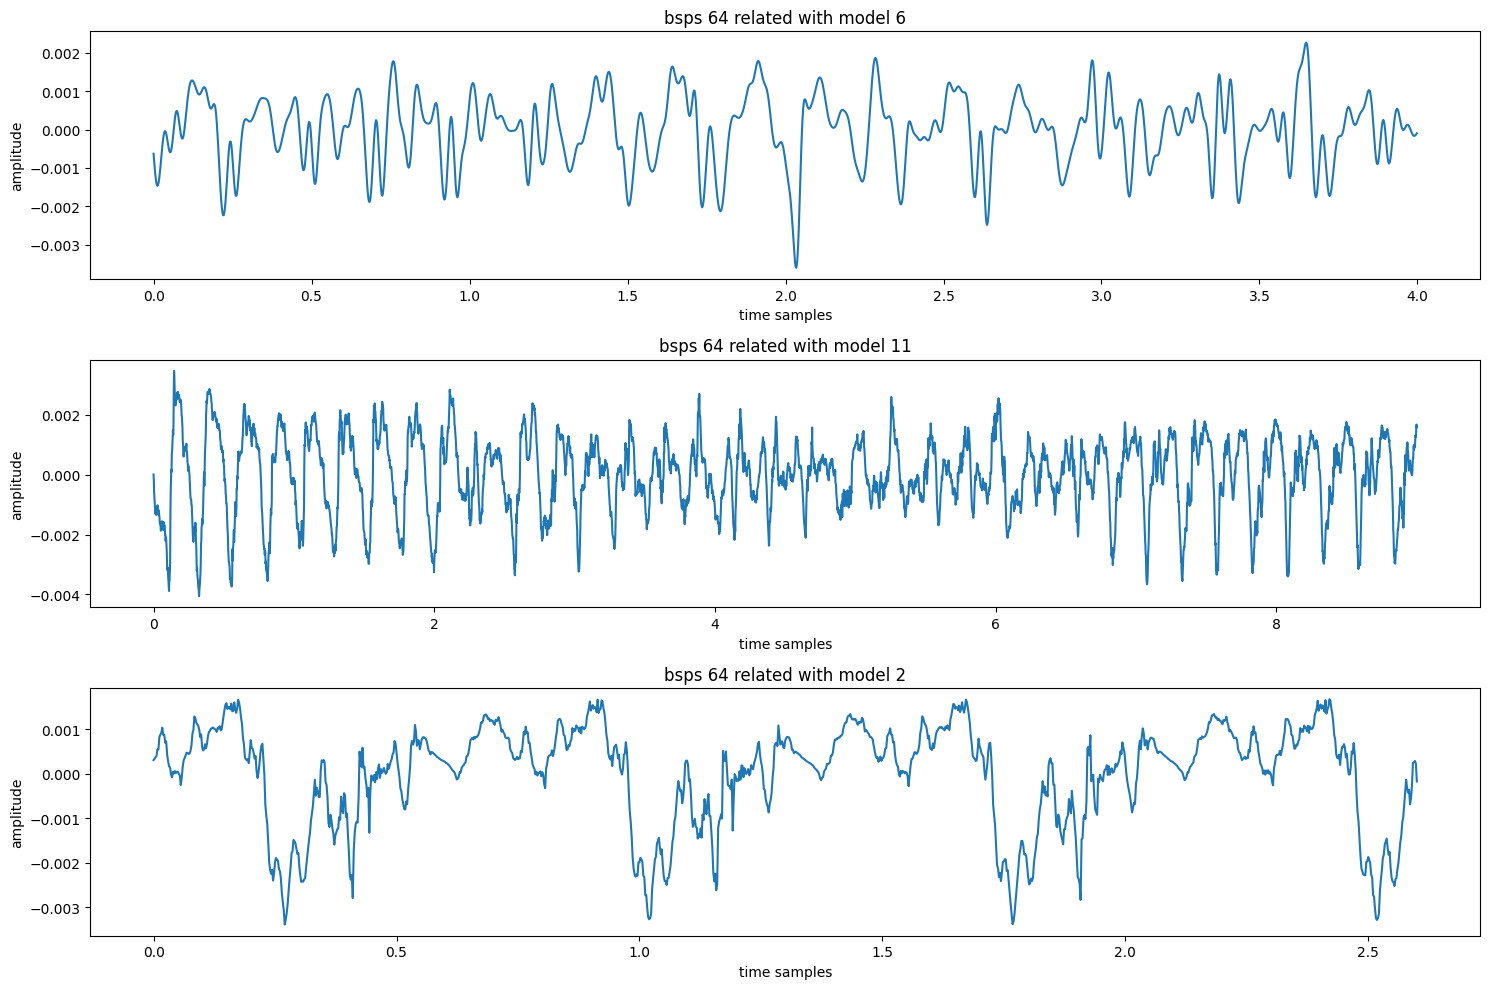

In [19]:
#plotting bsps

random_ind = random.sample(range(len(bsps_64_all_models)), 3)
fig, axs = plt.subplots(3, 1, figsize=(15, 10))


for i, idx in enumerate(random_ind):
    signal = bsps_64_all_models[idx][0, :] -np.mean(bsps_64_all_models[idx][0, :])

    t = np.arange(len(signal))/500
    axs[i].plot(t, signal) 
    axs[i].set_title(f'bsps 64 related with model {idx}')  
    axs[i].set_xlabel('time samples')
    axs[i].set_ylabel('amplitude')

plt.tight_layout()
plt.show()

SACO SPECTROGRAM DE FOURIER

In [20]:
print(len(bsps_64_all_models))

print(bsps_64_all_models[0][0,:].shape)  # primer nodo (de 64) del primer modelo (de 12)

bsps_ex_signal_all_models = []
for i in range(len(bsps_64_all_models)):

    bsps_ex_signal = bsps_64_all_models[i][0,:].reshape(1,-1)  # si pongo [1,:] me quedo con el segundo nodo y asi sucesivamente
    print(bsps_ex_signal.shape)
    bsps_ex_signal[0].shape
    bsps_ex_signal_all_models.append(bsps_ex_signal)

12
(1500,)
(1, 1500)
(1, 2499)
(1, 1301)
(1, 1500)
(1, 4000)
(1, 4000)
(1, 2000)
(1, 2000)
(1, 2001)
(1, 2499)
(1, 2499)
(1, 4501)


1500


Text(0, 0.5, 'amplitude')

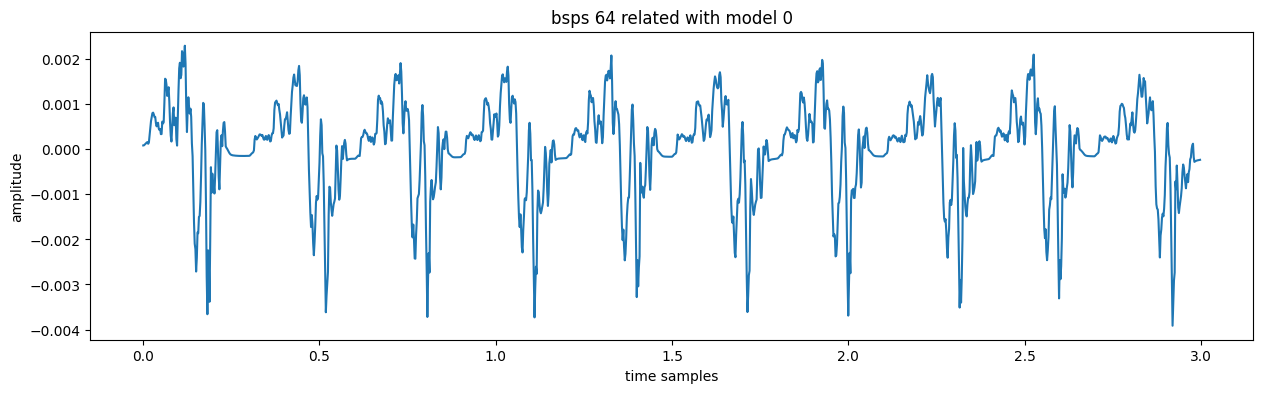

In [21]:
bsps_64_all_models[0][0,:].shape
bsps_ex_signal = bsps_64_all_models[0][0,:].reshape(1,-1)

t = np.arange(len(bsps_ex_signal[0]))/500
print(len(t))
plt.figure(figsize=(15, 4))
plt.plot(t, bsps_ex_signal[0] -np.mean(bsps_ex_signal[0]))
plt.title('bsps 64 related with model 0')
plt.xlabel('time samples')
plt.ylabel('amplitude')

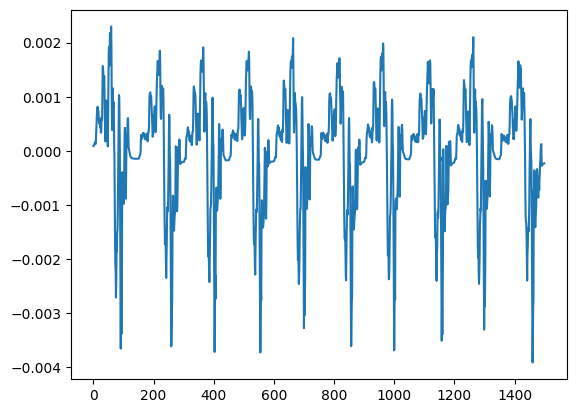

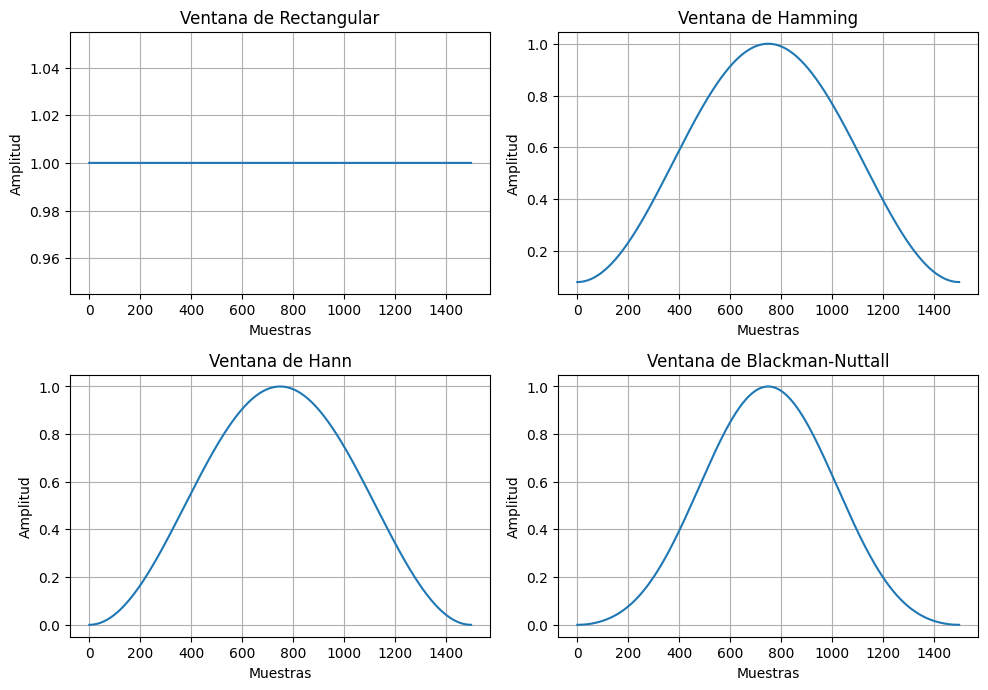

In [22]:
# Crear una figura con múltiples subgráficos
plt.figure()
signal = bsps_64_all_models[0][0] - np.mean(bsps_64_all_models[0][0])
plt.plot(signal)
N = len(signal)
# Ventanas y sus nombres
ventanas = [np.ones(N), np.hamming(N), np.hanning(N), np.blackman(N)]
nombres = ['Rectangular', 'Hamming', 'Hann', 'Blackman-Nuttall']
plt.figure(figsize=(10, 10))
# Mostrar cada ventana
for i, ventana in enumerate(ventanas):
    plt.subplot(3, 2, i+1)  # 3 filas, 2 columnas
    plt.plot(ventana)
    plt.title(f"Ventana de {nombres[i]}")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True)

plt.tight_layout()
plt.show()


1500


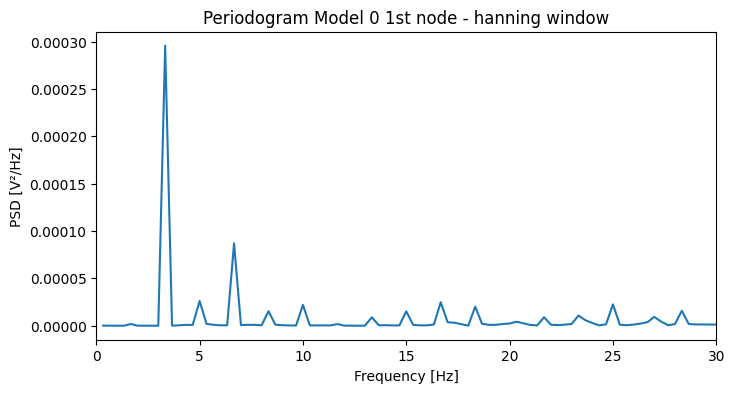

In [23]:
#PERIODOGRAMA A SECAS FFT --> SIN VENTANA (O RECTANGULAR)

fs = 500  
signal = bsps_64_all_models[0][0] 
N = len(signal)
print(N)

window = np.ones(N)
windowed_signal = (signal-np.mean(signal)) * window

fft_signal = np.fft.fft(windowed_signal)
frequencies = np.fft.fftfreq(N, d=1/fs)

# Calcular el periodograma
Pxx = (np.abs(fft_signal)**2) / N 
positive_freqs = frequencies[:N//2]
positive_Pxx = Pxx[:N//2]

# Filtrar frecuencias mayores que 0 para evitar log(0)
mask = positive_freqs > 0  
positive_freqs = positive_freqs[mask] 
positive_Pxx = positive_Pxx[mask] 

plt.figure(figsize=(8, 4))
plt.plot(positive_freqs, positive_Pxx) 
plt.xlim(0,30)
plt.title("Periodogram Model 0 1st node - hanning window")
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.show()

1500


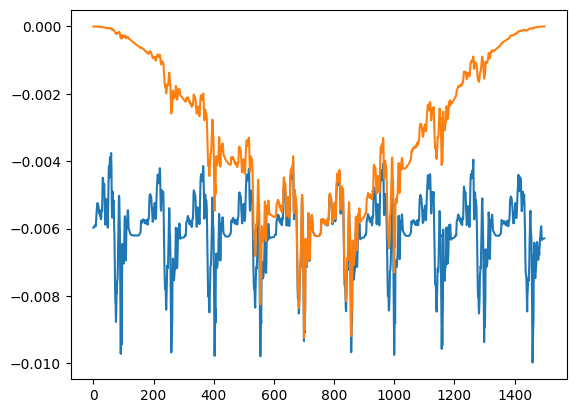

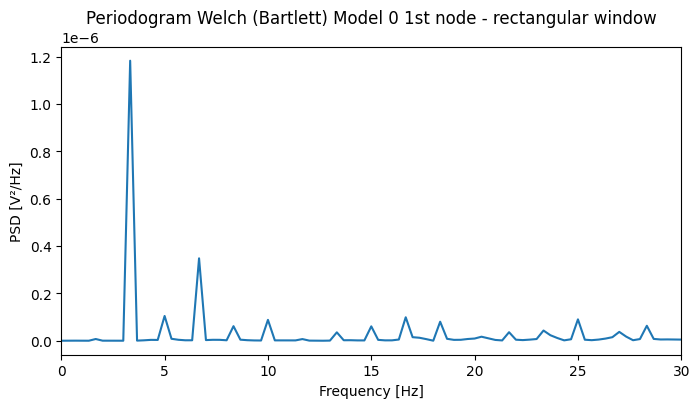

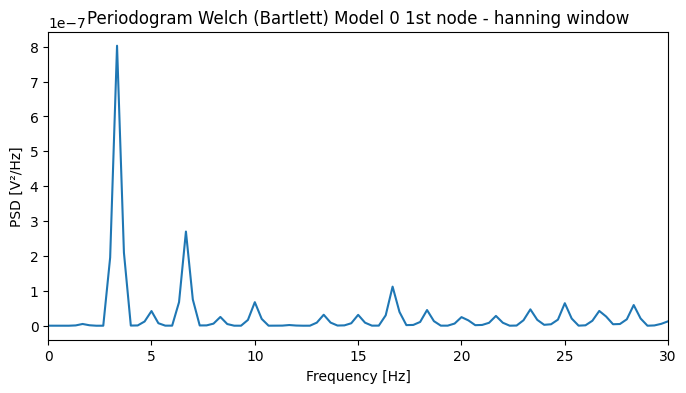

In [24]:
#PERIODOGRAMA Welch --> BARTLETT PERIODOGRAM

fs = 500  
signal = bsps_64_all_models[0][0] 
N = len(signal)
print(N)

window_1 = np.ones(N)
window_hann = np.hanning(N)
windowed_signal_1 = signal * window_1
windowed_signal_hann = signal * window_hann


plt.figure()
plt.plot(windowed_signal_1)
plt.plot(windowed_signal_hann)


import scipy.signal as sc
f, p = sc.welch(signal, fs=500, window='boxcar', nperseg=len(signal), noverlap=0, nfft=len(signal))
f, p_h = sc.welch(signal, fs=500, window='hann', nperseg=len(signal), noverlap=0, nfft=len(signal))


plt.figure(figsize=(8, 4))
plt.plot(f, p) 
plt.xlim(0,30)
plt.title("Periodogram Welch (Bartlett) Model 0 1st node - rectangular window")
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(f, p_h) 
plt.xlim(0,30)
plt.title("Periodogram Welch (Bartlett) Model 0 1st node - hanning window")
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.show()


PERIODOGRAMA DE WELCH --> Para ver los picos de energia

(1500,)


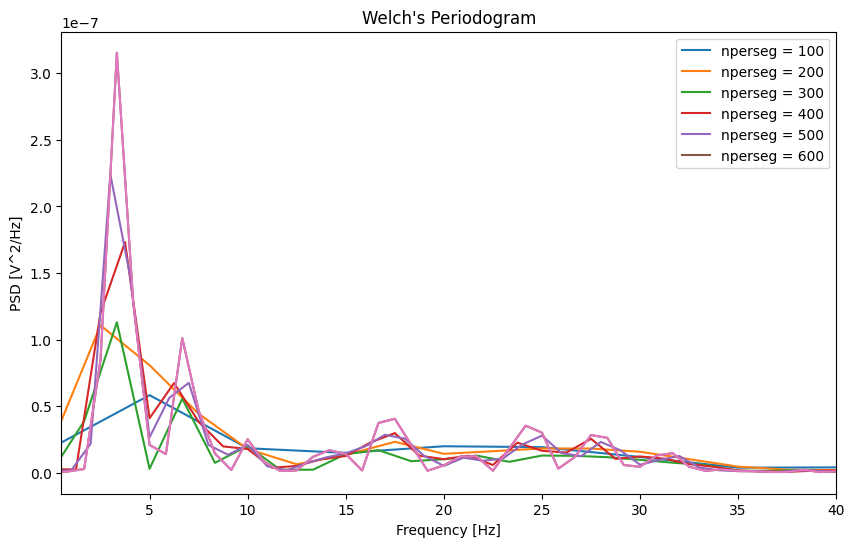

In [25]:
#ploteamos para un nodo y un solo modelo el periodograma de welch con diferentes nperseg para encontrar cual nos da mejor resultado
print(bsps_ex_signal_all_models[0][0].shape)

from scipy.signal import welch
plt.figure(figsize=(10, 6))

nperseg = [100, 200, 300, 400, 500, 600]

for i in range(len(nperseg)):
    freq, psd = welch(bsps_64_all_models[0][0], fs=500, nperseg=nperseg[i], noverlap=0, nfft = nperseg[i], window=np.hanning(nperseg[i]))
    plt.plot(freq, psd, label=f'nperseg = {nperseg[i]}')   # --> vemos que sale mejor con nperseg = 600


plt.plot(freq, psd)
plt.title("Welch's Periodogram")
plt.xlabel("Frequency [Hz]")
plt.xlim(0.5, 40)  # --> acotamos el eje x para ver mejor porque cardiac signal estan en un rango menor que 100 hz
plt.ylabel("PSD [V^2/Hz]")
plt.legend()
plt.show()

(1500,)


/tmp/ipykernel_2965134/619498941.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


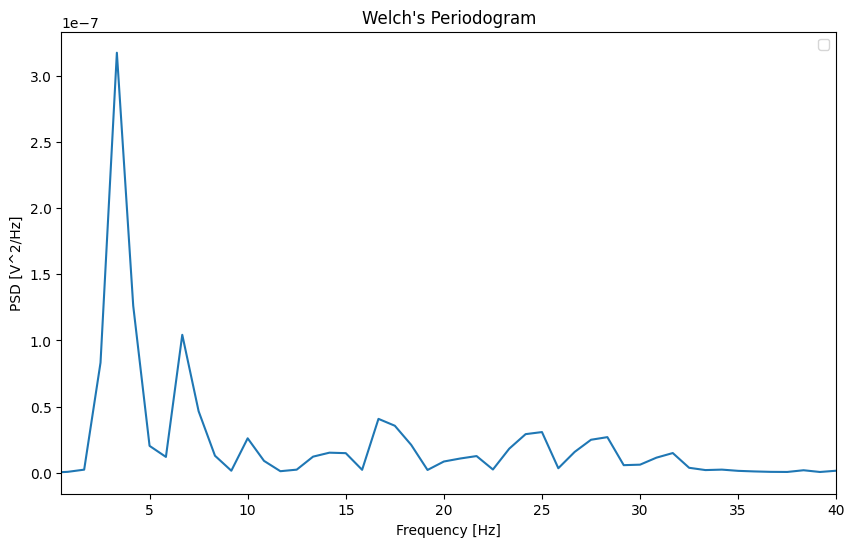

In [26]:
#ploteamos para un nodo y un solo modelo el periodograma de welch con diferentes nperseg para encontrar cual nos da mejor resultado
#NPERSEG = 600

print(bsps_ex_signal_all_models[0][0].shape)

from scipy.signal import welch
plt.figure(figsize=(10, 6))

nperseg = 600

freq, psd = welch(bsps_64_all_models[0][0], fs=500, nperseg=nperseg, noverlap=nperseg // 2)
plt.plot(freq, psd)   # --> vemos que sale mejor con nperseg = 600

plt.title("Welch's Periodogram")
plt.xlabel("Frequency [Hz]")
plt.xlim(0.5, 40)  # --> acotamos el eje x para ver mejor porque cardiac signal estan en un rango menor que 100 hz
plt.ylabel("PSD [V^2/Hz]")
plt.legend()
plt.show()

(1500,)


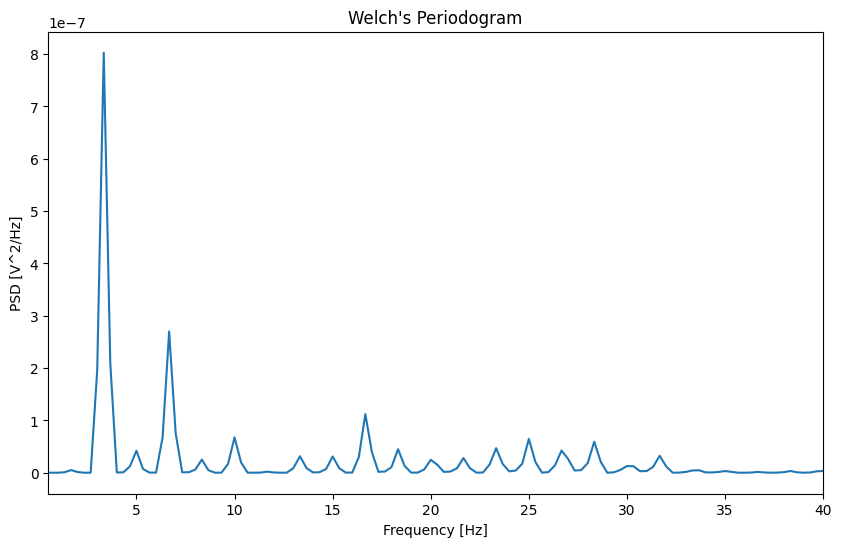

In [27]:
#ploteamos para un nodo y un solo modelo el periodograma de welch con 
#       - nperseg = len signal
#       - noverlap = 0
#       - nfft = len signal


print(bsps_64_all_models[0][0].shape)

from scipy.signal import welch
plt.figure(figsize=(10, 6))

nperseg = 600
len_signal = len(bsps_64_all_models[0][0])

freq, psd = welch(bsps_64_all_models[0][0], fs=500, nperseg=len_signal, noverlap=0, nfft=len_signal, window='hann')
plt.plot(freq, psd)  

plt.title("Welch's Periodogram")
plt.xlabel("Frequency [Hz]")
plt.xlim(0.5, 40)  # --> acotamos el eje x para ver mejor porque cardiac signal estan en un rango menor que 40 hz
plt.ylabel("PSD [V^2/Hz]")
plt.show()

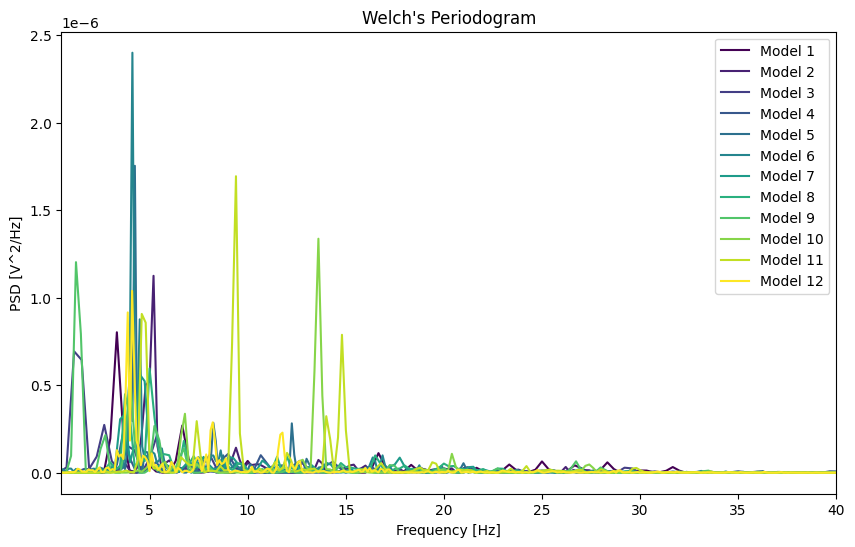

In [28]:


plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(bsps_64_all_models)))  # Generar una lista de colores

nperseg=600
for i in range(len(bsps_64_all_models)):

    freq, psd = welch(bsps_64_all_models[i][0], fs=500, nperseg=len(bsps_64_all_models[i][0]), noverlap=0, nfft=len(bsps_64_all_models[i][0]))

    plt.plot(freq, psd, label=f'Model {i+1}', color=colors[i])

plt.title("Welch's Periodogram")
plt.xlabel("Frequency [Hz]")
plt.xlim(0.5, 40) 
plt.ylabel("PSD [V^2/Hz]")
plt.legend()  
   
plt.show()


1500


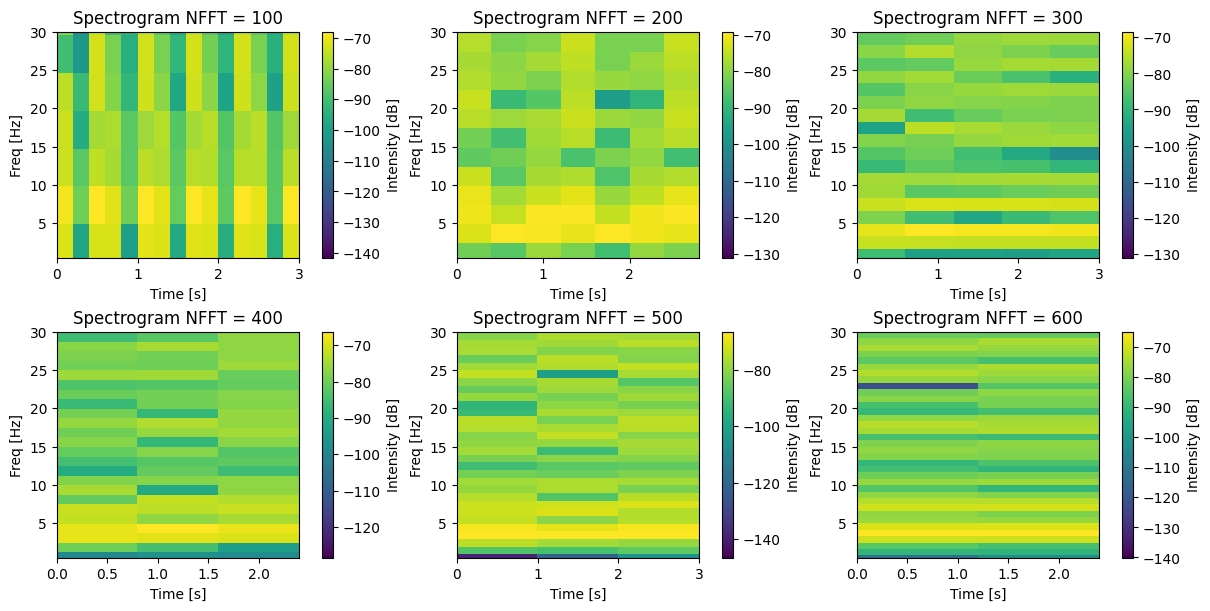

In [29]:
#aqui estoy haciendo el spectrogram para un solo nodo y un solo modelo

# como vemos en el periodograma anterior, la intensidad mas alta se obtiene en esas frecuencias en el rango 0-10 hz aprox
# linea amarilla mucho mas intensa que las demas que se mantiene en el tiempo porque la señal es periodica

#como es periódica tenemos los mismos componentes frecuenciales en toda la longitud temporal de la señal
#los 5 Hz (lo que sale amarillo) es una componente frecuencial constante, que es el ritmo al que salen los latidos má o menos
print(len(bsps_64_all_models[0][0,:]))
#plt.figure(figsize=(8, 4))
signal = bsps_64_all_models[0][0, :]
nffts = [100, 200, 300, 400, 500, 600]

fig, axarr = plt.subplots(nrows=2, ncols=3, figsize=(12, 6), constrained_layout=True)  # Ajuste automático

im = None  # Para almacenar el último espectrograma

for i, ax in enumerate(axarr.flat):  
    ax.specgram(signal-np.mean(signal), Fs=500, NFFT=nffts[i], noverlap=0, window=np.hanning(nffts[i]))
    ax.set_title(f"Spectrogram NFFT = {nffts[i]}")
    ax.set_xlabel("Time [s]")
    ax.set_ylim(0.5, 30)
    ax.set_ylabel("Freq [Hz]")
    fig.colorbar(ax.images[0], ax=ax, label='Intensity [dB]')
    

plt.show()




'\n\n# spectrograms with different windows\nplt.figure(figsize=(8, 15))\n\nfor i, (nombre, window) in enumerate(windows.items()):\n    plt.subplot(len(windows), 1, i + 1)  \n    plt.specgram(signal, Fs=fs, NFFT=nperseg, noverlap=noverlap, window=window)\n    plt.title(f"Spectrogram with window {nombre}")\n    plt.xlabel("Time [s]")\n    plt.ylabel("Frequency [Hz]")\n    plt.colorbar(label="Intensity [dB]")\n    plt.ylim(0.5, 30) \n\nplt.tight_layout()\nplt.show()\n'

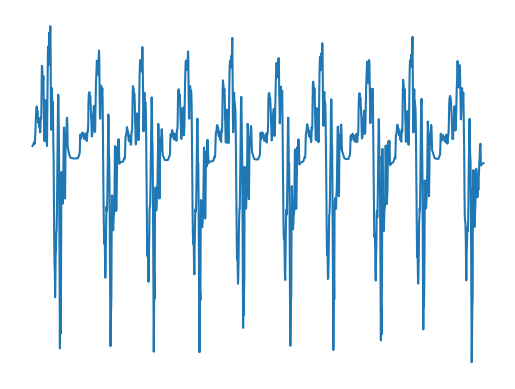

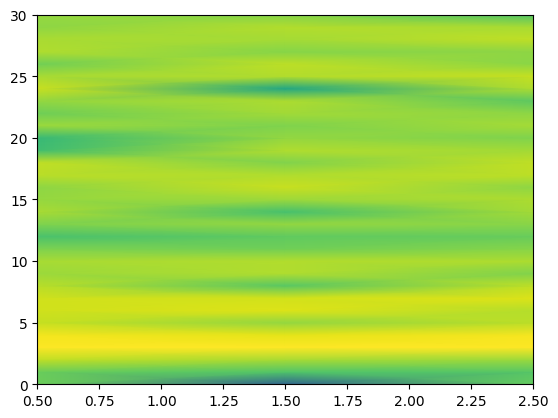

In [31]:
import scipy.signal as sc
# Señal de entrada
signal = bsps_64_all_models[0][0, :]
nperseg = len(signal) 
noverlap = 0
fs = 500 

windows = {
    "Rectangular": np.ones(nperseg),
    "Hamming": np.hamming(nperseg),
    "Hann": np.hanning(nperseg),
    "Blackman": np.blackman(nperseg)
}

t = np.arange(len(signal))/fs
plt.plot(t,signal)
plt.axis('off')
plt.figure()

f, t, Sxx = sc.spectrogram(signal, fs=500, window='hann', nperseg=500, noverlap=0, nfft=None)

plt.pcolormesh(t, f, np.log10(Sxx), shading='gouraud')
plt.ylim(0,30)
"""

# spectrograms with different windows
plt.figure(figsize=(8, 15))

for i, (nombre, window) in enumerate(windows.items()):
    plt.subplot(len(windows), 1, i + 1)  
    plt.specgram(signal, Fs=fs, NFFT=nperseg, noverlap=noverlap, window=window)
    plt.title(f"Spectrogram with window {nombre}")
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.colorbar(label="Intensity [dB]")
    plt.ylim(0.5, 30) 

plt.tight_layout()
plt.show()
"""

12
(4000,)


<Figure size 1600x400 with 0 Axes>

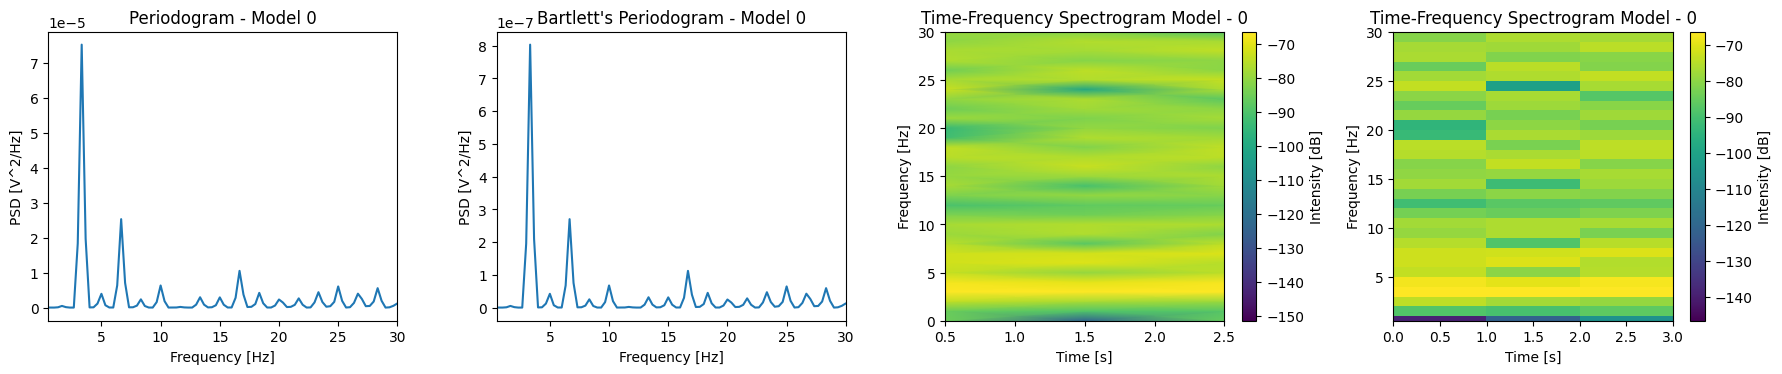

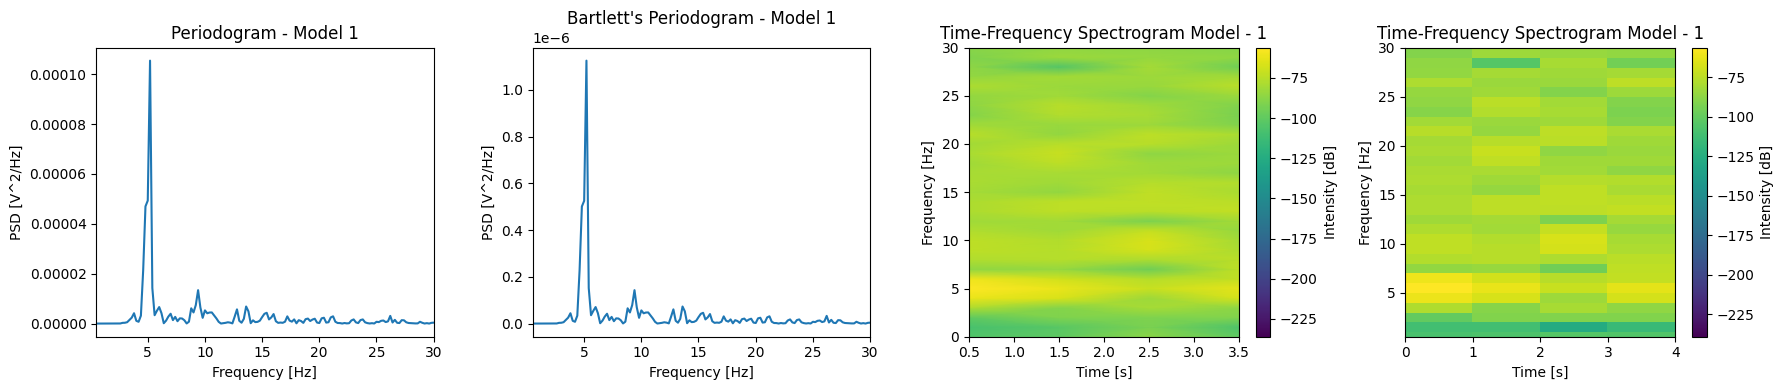

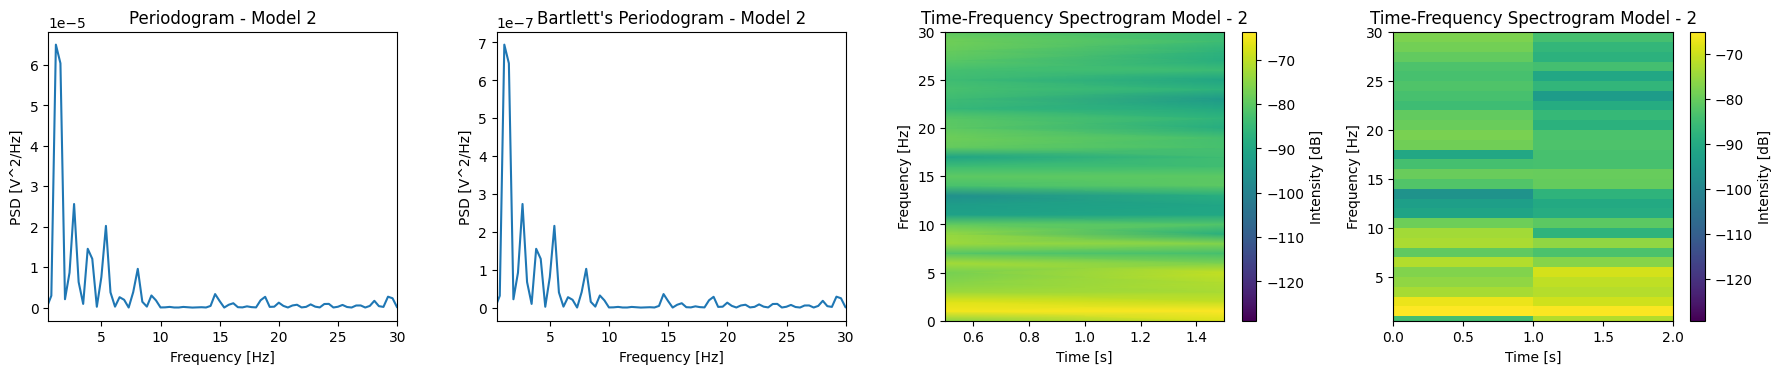

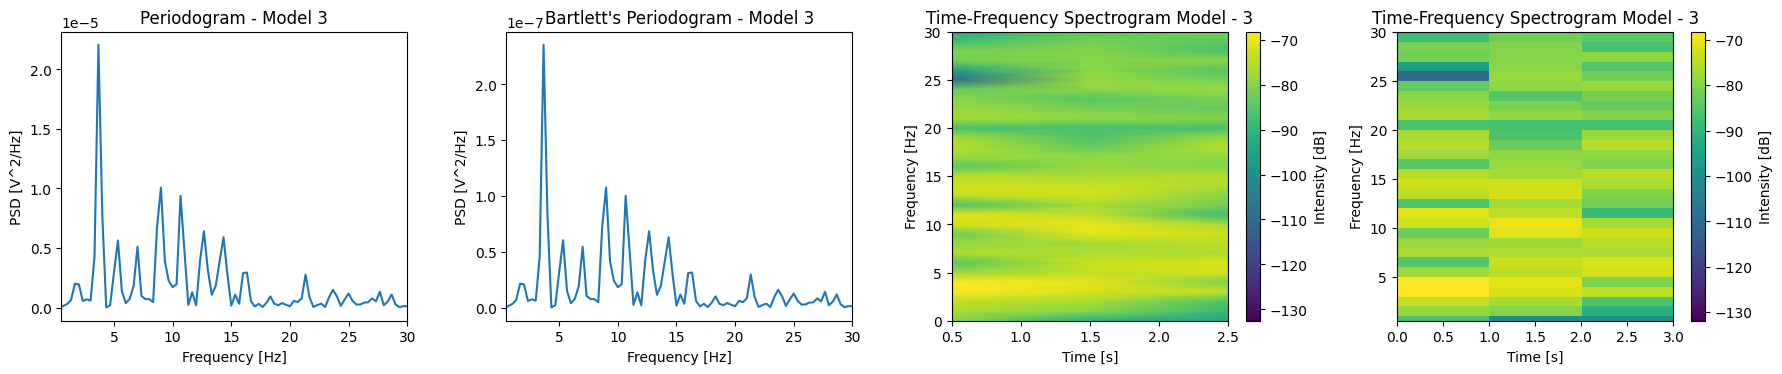

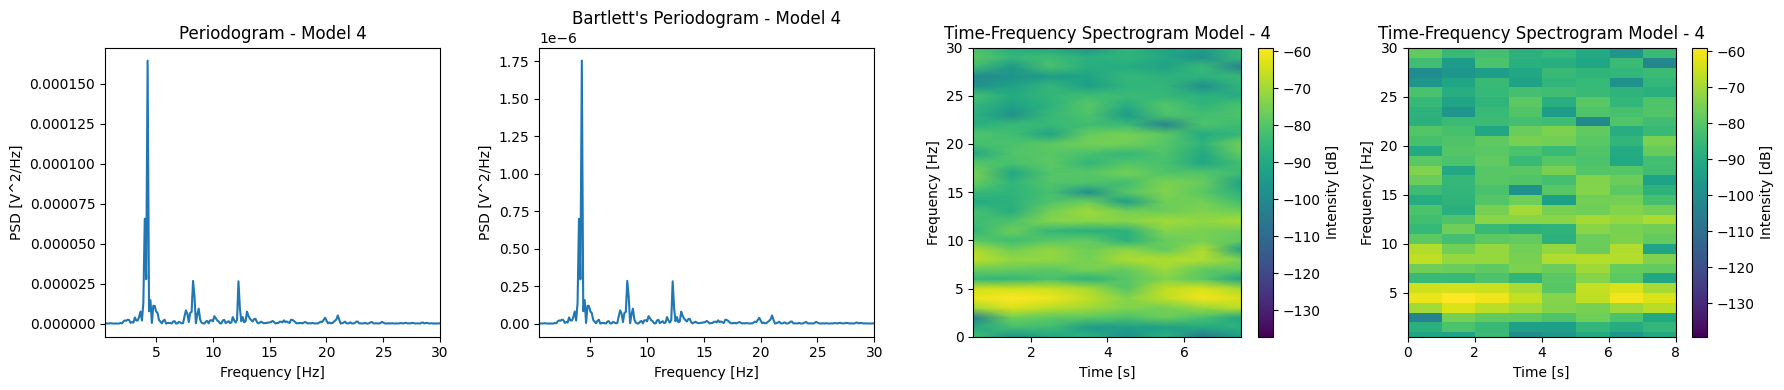

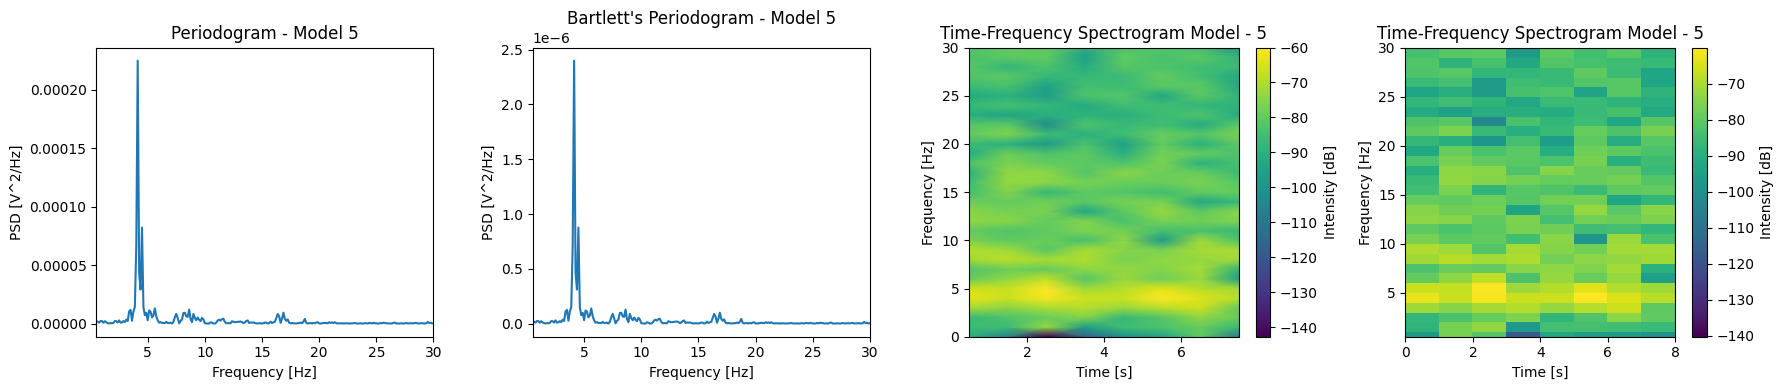

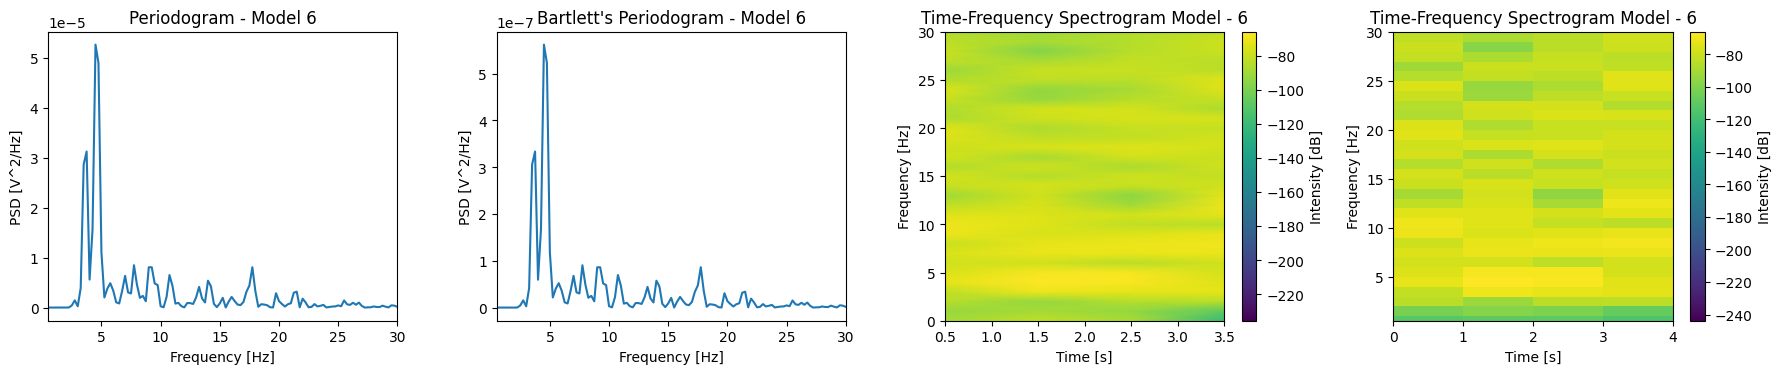

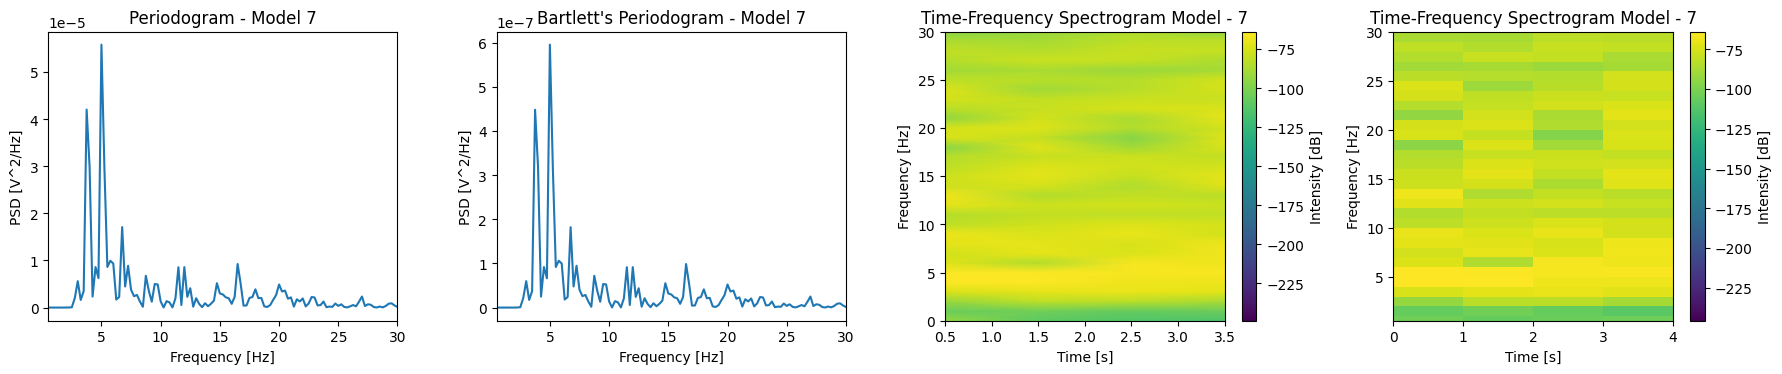

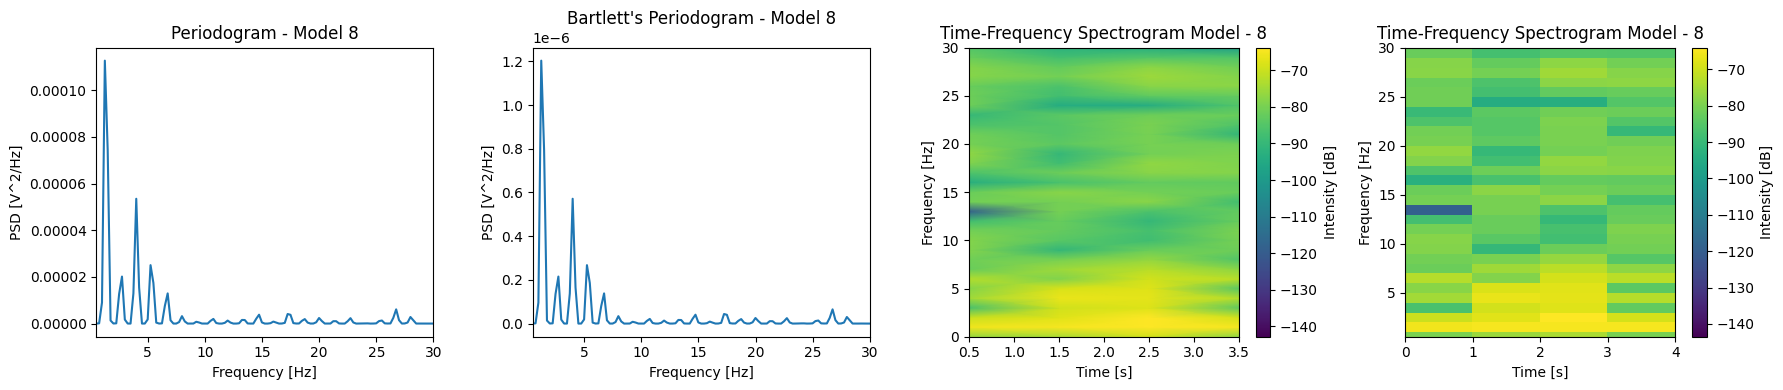

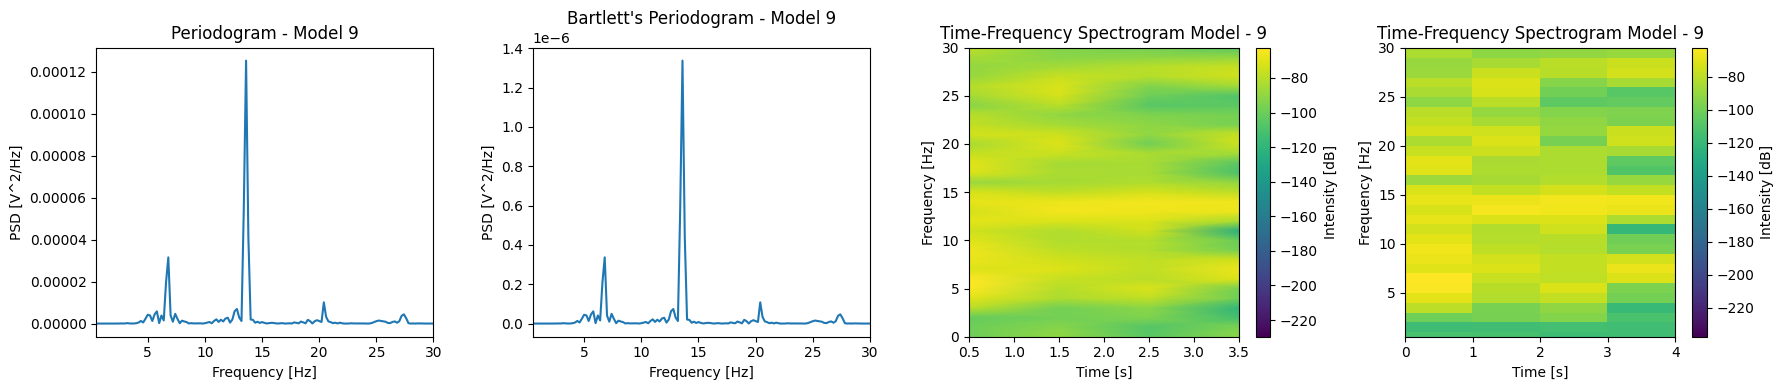

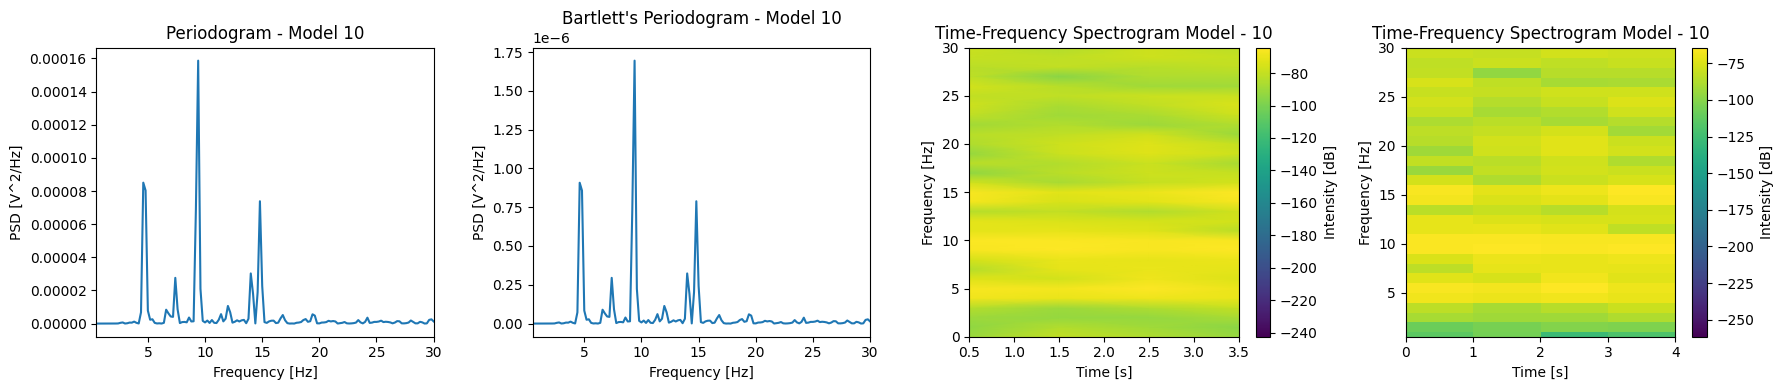

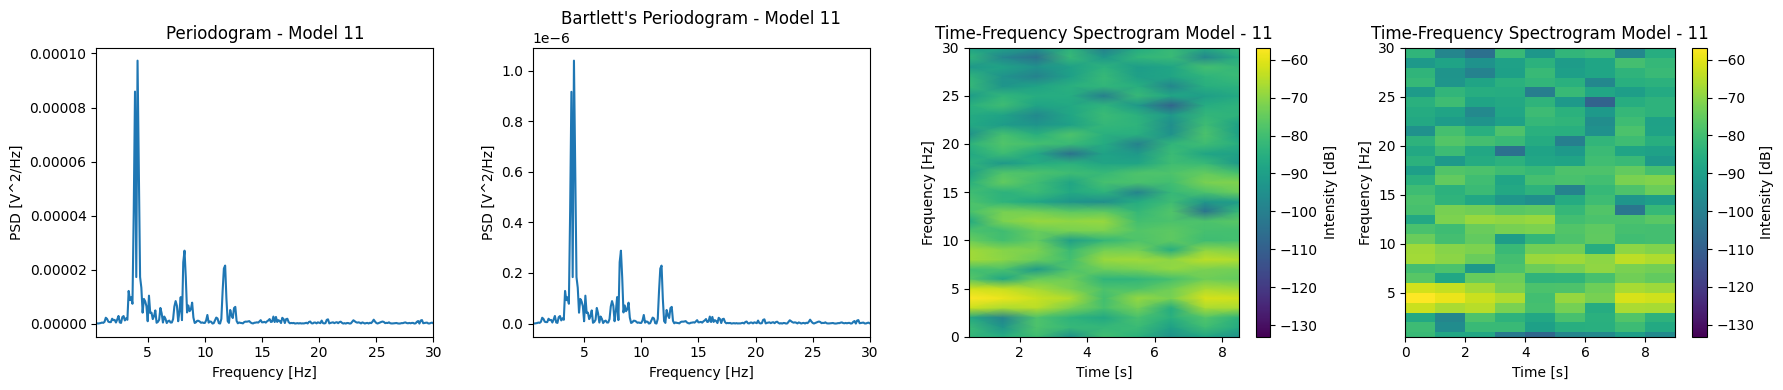

In [32]:
#welch periodoram y sprecrogram para todos los modelos para un solo nodo
from scipy.signal import welch

print(len(bsps_64_all_models))
print(bsps_ex_signal_all_models[4][0,:].shape)

plt.figure(figsize=(16, 4))
for i in range(len(bsps_64_all_models)):

    signal = bsps_64_all_models[i][0]

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18, 4))  

    # Periodogram
    N = len(signal)
    window = np.hanning(N)
    windowed_signal = (signal-np.mean(signal)) * window

    fft_signal = np.fft.fft(windowed_signal)
    frequencies = np.fft.fftfreq(N, d=1/fs)
    Pxx = (np.abs(fft_signal)**2) / N 

    positive_freqs = frequencies[:N//2]
    positive_Pxx = Pxx[:N//2]

    # Filtrar frecuencias mayores que 0 para evitar log(0)
    mask = positive_freqs > 0  
    positive_freqs = positive_freqs[mask] 
    positive_Pxx = positive_Pxx[mask] 

    ax1.plot(positive_freqs, positive_Pxx) 
    ax1.set_title(f"Periodogram - Model {i}")
    ax1.set_xlabel("Frequency [Hz]")
    ax1.set_ylabel("PSD [V^2/Hz]")
    ax1.set_xlim(0.5, 30)


    # welch pspectrogram
    freq, psd = welch(signal, fs=500, nperseg=len(signal), noverlap=0, nfft=len(signal), scaling='density')
    ax2.plot(freq, psd)
    ax2.set_title(f"Bartlett's Periodogram - Model {i}")
    ax2.set_xlabel("Frequency [Hz]")
    ax2.set_ylabel("PSD [V^2/Hz]")
    ax2.set_xlim(0.5, 30)  
    
    # spectrogram a mano
    f, t, Sxx = sc.spectrogram(signal-np.mean(signal), fs=500, window='hann', nperseg=500, noverlap=0, nfft=None)
    pcm = ax3.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
    ax3.set_ylim(0,30)
    ax3.set_title(f"Time-Frequency Spectrogram Model - {i}")
    ax3.set_xlabel("Time [s]")
    ax3.set_ylabel("Frequency [Hz]")
    #ax3.set_xlim(0, len(signal)/500) 
    fig.colorbar(pcm, ax=ax3, label="Intensity [dB]")

    #func specgram
    ax4.specgram(signal-np.mean(signal), Fs=500, NFFT=500, noverlap=0, window=np.hanning(500))
    ax4.set_title(f"Time-Frequency Spectrogram Model - {i}")
    ax4.set_xlabel("Time [s]")
    ax4.set_ylabel("Frequency [Hz]")
    ax4.set_ylim(0.5, 30) 
    fig.colorbar(ax4.images[0], ax=ax4, label='Intensity [dB]')
    #ax4.images[0].set_clim(-100, -50)


    plt.tight_layout()


plt.show()